# Packages, constants, and useful routines

In [1]:
!pip install -Uq pymcel rebound

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
import numpy as np
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import spiceypy as spy

deg = np.pi/180
rad = 1/deg

Bienvenido a PyMCel v0.9.21 ¡al infinito y más allá!


# Conic sections

Suppose we want to connect two conics: a hyperbola with respect to Earth and an ellipse with respect to the Sun, with the following parameters:

Hyperbolic orbit properties:

In [3]:
muh = pc.constantes.GM_earth

# Departure distance and direction
rph = 1000e3 # 1000 km
#betah = 30*deg # Angle

# Hyperbola elements
eh = 2.3
Ih = 0.0*deg
# omegah: the argument of periapsis is set later
Omegah = 0.0*deg
Mh = 0.0*deg # periapsis departure

Planet orbit properties:

In [4]:
mue = pc.constantes.GM_sun

rpe = 1*pc.constantes.au
ee = 0.3
Ie = 0.0*deg
omegae = 0.0*deg
Omegae = 0.0*deg
Me = 0.0*deg

We calculate the initial position and velocity on the elliptical orbit:

In [5]:
Xe_ini = spy.conics([rpe, ee, Ie, Omegae, omegae, Me, 0, mue], 0)
re_ini = Xe_ini[:3]
ve_ini = Xe_ini[3:]
re_ini, ve_ini

(array([1.49597871e+11, 0.00000000e+00, 0.00000000e+00]),
 array([   -0.        , 33959.77366835,     0.        ]))

Using the departure velocity, we can correctly orient the hyperbolic orbit:

This is the velocity angle of the point on the elliptical orbit:

In [6]:
teta_ve_ini = np.arctan2(ve_ini[1], ve_ini[0])
teta_ve_ini*rad

np.float64(90.0)

With this angle, we can set the argument of periapsis of the departure orbit. The opening angle is:

In [7]:
beta = np.arccos(1/eh)
beta*rad

np.float64(64.22853825944934)

Therefore, the angle between periapsis and the velocity direction is:

In [8]:
teta_inf = np.pi - beta
teta_inf*rad

np.float64(115.77146174055066)

The argument of periapsis with respect to the x-axis is:

In [9]:
omegah = teta_ve_ini - teta_inf
omegah*rad

np.float64(-25.77146174055066)

The initial position on the hyperbolic orbit will be:

In [10]:
Xh_ini = spy.conics([rph, eh, Ih, Omegah, omegah, Mh, 0, muh], 0)
rh_ini = Xh_ini[:3]
vh_ini = Xh_ini[3:]
rh_ini, vh_ini, np.linalg.norm(rh_ini)/1e3, np.linalg.norm(vh_ini)/1e3

(array([ 900535.4424873 , -434782.60869565,      -0.        ]),
 array([15768.77654733, 32660.78698073,     0.        ]),
 np.float64(999.9999999999999),
 np.float64(36.2681860588588))

Let us verify the angle formed by the departure velocity relative to the velocity on the elliptical orbit:

In [11]:
teta_ve_vh = np.arccos((ve_ini@vh_ini)/(np.linalg.norm(ve_ini)*np.linalg.norm(vh_ini)))
teta_ve_vh*rad, 90 -beta*rad

(np.float64(25.77146174055065), np.float64(25.771461740550663))

## Departure point to the SoI

We can now propagate the position along the hyperbolic orbit, either in time or in mean anomaly:

In [12]:
t = 12*3600 # 3 horas
Xh = spy.conics([rph, eh, Ih, Omegah, omegah, Mh, 0, muh], t)
rh = Xh[:3]
vh = Xh[3:]
rh, vh, np.linalg.norm(rh)/1e3/1e3, np.linalg.norm(vh)

(array([1.59263527e+06, 9.88016966e+08, 0.00000000e+00]),
 array([1.42785764e-02, 2.27812947e+04, 0.00000000e+00]),
 np.float64(988.0182494694791),
 np.float64(22781.29470633841))

Let us see how different the velocity is from the velocity at infinity:

In [13]:
ah = rph / (1 - eh)
v_inf = np.sqrt(muh / abs(ah))
v_inf

np.float64(22763.578804748606)

We can also compare the distance with the radius of the sphere of influence:

In [14]:
rSOI = np.linalg.norm(re_ini) * (muh / mue)**(2/5)
rSOI / 1e3 / 1e3

np.float64(924.6467563688643)

How long does it take to reach the sphere of influence? We can calculate it using:

$$
r_\mathrm{SoI} = \frac{p}{1+e\cos\theta_\mathrm{SoI}}
$$

and considering that:

$$
\tanh(F_\mathrm{SoI}/2) = \sqrt{\frac{e-1}{e+1}}\tan (\theta_\mathrm{SoI}/2) \\
M_\mathrm{SoI} = e\sinh F_\mathrm{SoI} - F_\mathrm{SoI}
$$
where

$$
M_\mathrm{SoI} = nt
$$
and

$$
n^2 |a|^3 = \mu
$$

The true anomaly at the sphere of influence is:

In [15]:
ph = rph * (1 + eh)
teta_SoI = np.arccos(((ph/rSOI) - 1)/eh)
teta_SoI*rad

np.float64(115.67277660225305)

The eccentric anomaly:

In [16]:
F_SoI = 2*np.arctanh(np.sqrt((eh-1)/(eh+1)) * np.tan(teta_SoI/2))
M_SoI = eh * np.sinh(F_SoI) - F_SoI
M_SoI * rad

np.float64(68530.66483329433)

With this value, we can predict the position:

In [17]:
Xh = spy.conics([rph, eh, Ih, Omegah, omegah, M_SoI, 0, muh], 0)
rh = Xh[:3]
vh = Xh[3:]
rh, vh, np.linalg.norm(rh)/1e6, np.linalg.norm(vh)

(array([1.59259283e+06, 9.24645385e+08, 0.00000000e+00]),
 array([1.63019680e-02, 2.27825084e+04, 0.00000000e+00]),
 np.float64(924.6467563690106),
 np.float64(22782.508377079917))

Or use the time:

In [18]:
n = np.sqrt(muh / abs(ah)**3)
t_SoI = M_SoI / n
t_SoI / 3600

np.float64(11.227315276028843)

The position and velocity:

In [19]:
Xh = spy.conics([rph, eh, Ih, Omegah, omegah, Mh, 0, muh], t_SoI)
rh = Xh[:3]
vh = Xh[3:]
rh, vh, np.linalg.norm(rh)/1e6, np.linalg.norm(vh)

(array([1.59259283e+06, 9.24645385e+08, 0.00000000e+00]),
 array([1.63019680e-02, 2.27825084e+04, 0.00000000e+00]),
 np.float64(924.6467563690106),
 np.float64(22782.508377079917))

## Orbit propagation

Given the spacecraft's position and velocity at the sphere of influence, we can propagate it with respect to the Sun. For this, we can use the `prop_2b` routine.

In [20]:
Xs = list(rh + re_ini) + list(vh + ve_ini)

te = 180*86400 # 30 días
spy.prop2b(mue, Xs, te)

array([-6.15505427e+10,  7.06484611e+11,  0.00000000e+00, -1.54785244e+04,
        3.97514675e+04,  0.00000000e+00])

The orbital elements can also be found:

In [21]:
rps, es, Is, Omegas, omegas, Ms, t, mus, tetas, asol, Psol = spy.oscltx(Xs, 0, mue)
es

np.float64(2.6294026506616244)

# Example 8.4

Problem data:

In [22]:
r_parqueo = 300e3
r_earth = pc.constantes.R_earth
mu_earth = pc.constantes.GM_earth
mu_sun = pc.constantes.GM_sun
r_orbit_e = 148.6e9
r_orbit_ma = 227.9e9

In [23]:
v_inf = ((np.sqrt(mu_sun/r_orbit_e)) *
        (np.sqrt(2 * r_orbit_ma / (r_orbit_e + r_orbit_ma)) - 1))
v_c = np.sqrt(mu_earth/(r_earth + r_parqueo))
delta_v = v_c * (np.sqrt(2 + (v_inf/v_c)**2) - 1)

# Eccentricity and beta
eh = (1 + (r_earth + r_parqueo) * v_inf**2 / mu_earth)
beta = np.arccos(1 / (eh))
np.rad2deg(beta)

np.float64(29.633601024450773)

In [24]:
v_inf, v_c, delta_v

(np.float64(2996.930433292831),
 np.float64(7725.781229237758),
 np.float64(3603.6928638559607))

In [25]:
mue = mu_sun

rpe = 1*pc.constantes.au
ee = 0.0
Ie = 0.0*deg
omegae = 0.0*deg
Omegae = 0.0*deg
Me = 0.0*deg

In [26]:
rpe

np.float64(149597870700.0)

In [27]:
Xe_ini = spy.conics([rpe, ee, Ie, Omegae, omegae, Me, 0, mue], 0)
re_ini = Xe_ini[:3]
ve_ini = Xe_ini[3:]
re_ini, ve_ini

(array([1.49597871e+11, 0.00000000e+00, 0.00000000e+00]),
 array([   -0.        , 29784.69182968,     0.        ]))

In [28]:
teta_ve_ini = np.arctan2(ve_ini[1], ve_ini[0])
teta_ve_ini*rad

np.float64(90.0)

In [29]:
muh = mu_earth

# Departure distance and direction
rph = r_earth + r_parqueo

# Hyperbola elements
eh = eh
Ih = 0.0*deg
# omegah: the argument of periapsis is set later
Omegah = 0.0*deg
Mh = 0.0*deg # periapsis departure

In [30]:
theta_inf = np.pi - beta
np.rad2deg(theta_inf)

np.float64(150.3663989755492)

In [31]:
eh, Ih, Omegah, Mh

(np.float64(1.1504764412732564), 0.0, 0.0, 0.0)

In [32]:
omegah = teta_ve_ini - theta_inf
omegah*rad

np.float64(-60.36639897554922)

In [33]:
Xh_ini = spy.conics([rph, eh, Ih, Omegah, omegah, Mh, 0, muh], 0)
rh_ini = Xh_ini[:3]
vh_ini = Xh_ini[3:]
rh_ini, vh_ini, np.linalg.norm(rh_ini)/1e3, np.linalg.norm(vh_ini)/1e3

(array([ 3301997.86852688, -5804638.63528505,       -0.        ]),
 array([9847.63675869, 5601.87767582,    0.        ]),
 np.float64(6678.099999999999),
 np.float64(11.329474093093719))

In [34]:
Xh_ini

array([ 3.30199787e+06, -5.80463864e+06, -0.00000000e+00,  9.84763676e+03,
        5.60187768e+03,  0.00000000e+00])

In [35]:
teta_ve_vh = np.arccos((ve_ini@vh_ini)/(np.linalg.norm(ve_ini)*np.linalg.norm(vh_ini)))
teta_ve_vh*rad, 90 - beta*rad

(np.float64(60.36639897554922), np.float64(60.36639897554923))

Sphere of influence:

In [36]:
rSOI = np.linalg.norm(re_ini) * (muh / mue)**(2/5)
rSOI / 1e3 / 1e3

np.float64(924.6467563688643)

In [37]:
ph = rph * (1 + eh)
ah = rph / (1 - eh)
teta_SoI = np.arccos(((ph/rSOI) - 1)/eh)
F_SoI = 2*np.arctanh(np.sqrt((eh-1)/(eh+1)) * np.tan(teta_SoI/2))
M_SoI = eh * np.sinh(F_SoI) - F_SoI

In [38]:
F_SoI = 2*np.arctanh(np.sqrt((eh-1)/(eh+1)) * np.tan(teta_SoI/2))
M_SoI = eh * np.sinh(F_SoI) - F_SoI
M_SoI*rad

np.float64(1040.9946985954534)

In [39]:
n = np.sqrt(muh / abs(ah)**3)
t_SoI = M_SoI / n

In [40]:
tsh = np.linspace(0, t_SoI, 1000)
xsh = []

for ts in tsh:
  estado_ini = spy.prop2b(muh, Xh_ini, ts)
  xsh.append(estado_ini[:3])
xsh = np.array(xsh)

In [41]:
xsh

array([[ 3.30199787e+06, -5.80463864e+06, -0.00000000e+00],
       [ 5.75860933e+06, -4.04689333e+06,  0.00000000e+00],
       [ 7.75510194e+06, -1.95246151e+06,  0.00000000e+00],
       ...,
       [ 2.46661020e+07,  9.22627635e+08,  0.00000000e+00],
       [ 2.46666084e+07,  9.23472670e+08,  0.00000000e+00],
       [ 2.46671138e+07,  9.24317671e+08,  0.00000000e+00]],
      shape=(1000, 3))

1. State vector for the body inside the SOI

In [42]:
xh_SoI = spy.prop2b(muh, Xh_ini, t_SoI)
rh_SoI = xh_SoI[:3]
vh_SoI = xh_SoI[3:]

2. State vector of the planet inside the SOI

In [43]:
xe_SoI = spy.prop2b(mue, Xe_ini, t_SoI)
re_SoI = xe_SoI[:3]
ve_SoI = xe_SoI[3:]

In [44]:
rs_SoI = rh_SoI + re_SoI
vs_SoI = vh_SoI + ve_SoI
xs_SoI = np.concatenate([rs_SoI, vs_SoI])

In [45]:
tsh_sun = np.linspace(0, 180*86400, 1000)
rsh_sun_spy = []

for ts in tsh_sun:
  estado_ini = spy.prop2b(mue, xs_SoI, ts)
  rsh_sun_spy.append(estado_ini[:3])
rsh_sun_spy = np.array(rsh_sun_spy)

In [46]:
rsh_earth = []
for ts in tsh_sun:
  estado_ini = spy.prop2b(mue, xs_SoI, ts)
  rsh_earth.append(estado_ini[:3])
rsh_earth = np.array(rsh_earth)


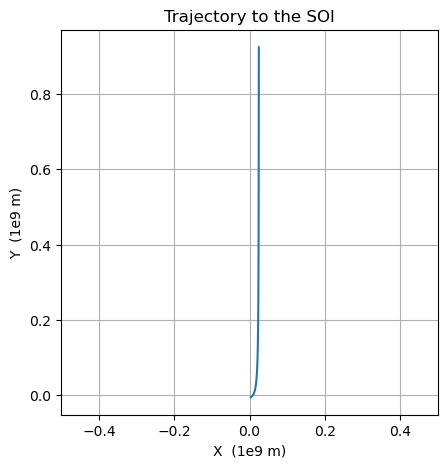

In [47]:
pio.renderers.default = "png"
plt.figure(figsize=(10, 5))
plt.plot(xsh [:, 0]/1e9, xsh [:, 1]/1e9)
plt.title('Trajectory to the SOI')
plt.xlabel('X  (1e9 m)')
plt.ylabel('Y  (1e9 m)')
plt.xlim([-0.5, 0.5])
plt.grid(True)
plt.gca().set_aspect('equal')

In [48]:
sim = rb.Simulation()
sim.units = ('m', 's', 'kg')
sim.add(m=pc.constantes.M_earth)
sim.add(m=0, x=Xh_ini[0], y=Xh_ini[1], z=Xh_ini[2], vx=Xh_ini[3], vy=Xh_ini[4], vz=Xh_ini[5])

In [49]:
xsh_rb = []
for ts in tsh:
  sim.integrate(ts)
  xsh_rb.append(sim.particles[1].xyz)
xsh_rb = np.array(xsh_rb)

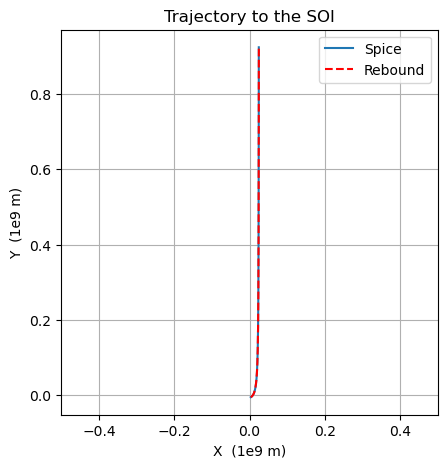

In [50]:
pio.renderers.default = "png"
plt.figure(figsize=(10, 5))
plt.plot(xsh [:, 0]/1e9, xsh [:, 1]/1e9, label='Spice')
plt.plot(xsh_rb [:, 0]/1e9, xsh_rb [:, 1]/1e9, 'r--', label='Rebound')
plt.title('Trajectory to the SOI')
plt.xlabel('X  (1e9 m)')
plt.ylabel('Y  (1e9 m)')
plt.xlim([-0.5, 0.5])
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()

The state vectors are calculated again, this time with rebound.

In [51]:
xh_SoI_rb =np.array([sim.particles[1].x, sim.particles[1].y, sim.particles[1].z,
                    sim.particles[1].vx, sim.particles[1].vy, sim.particles[1].vz])
rh_SoI_rb = xh_SoI_rb[:3]
vh_SoI_rb = xh_SoI_rb[3:]

In [52]:
rs_SoI_rb = rh_SoI_rb + re_SoI
vs_SoI_rb = vh_SoI_rb + ve_SoI
xs_SoI_rb = np.concatenate([rs_SoI_rb, vs_SoI_rb])

In [53]:
sim1 = rb.Simulation()
sim1.units = ('m', 's', 'kg')
sim1.add(m=pc.constantes.M_sun)
sim1.add(m=0, x=rs_SoI_rb[0], y=rs_SoI_rb[1], z=rs_SoI_rb[2],
              vx=vs_SoI_rb[0], vy=vs_SoI_rb[1], vz=vs_SoI_rb[2])

In [54]:
xsh_sun_rb = []
for ts in tsh_sun:
  sim1.integrate(ts)
  xsh_sun_rb.append(sim1.particles[1].xyz)
xsh_sun_rb = np.array(xsh_sun_rb)

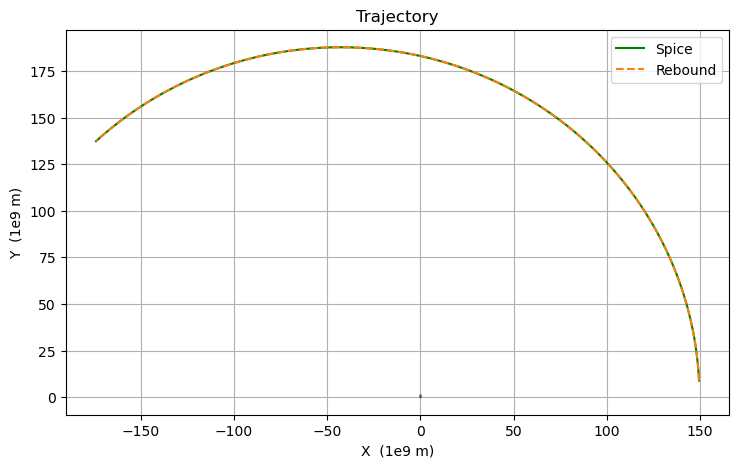

In [55]:
pio.renderers.default = "png"
plt.figure(figsize=(10, 5))
plt.plot(xsh [:, 0]/1e9, xsh [:, 1]/1e9)
plt.plot(xsh_rb [:, 0]/1e9, xsh_rb [:, 1]/1e9, 'r--')
plt.plot(rsh_sun_spy [:, 0]/1e9, rsh_sun_spy [:, 1]/1e9, 'g', label='Spice')
plt.plot(xsh_sun_rb [:, 0]/1e9, xsh_sun_rb [:, 1]/1e9, '--', label='Rebound')
plt.title('Trajectory')
plt.xlabel('X  (1e9 m)')
plt.ylabel('Y  (1e9 m)')
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()

Positions:

* For the hyperbolic orbit

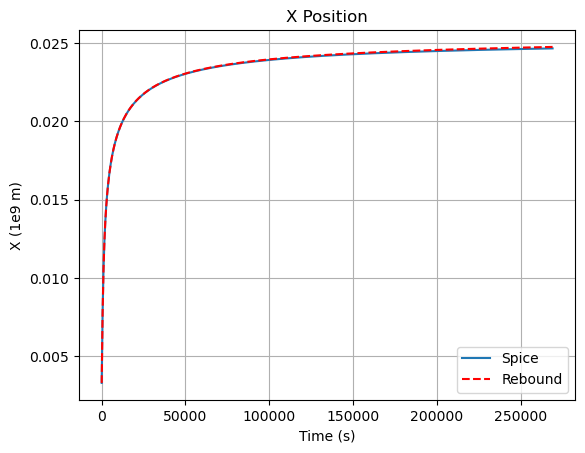

In [56]:
pio.renderers.default = "png"
plt.plot(tsh, xsh[:, 0]/1e9, label='Spice')
plt.plot(tsh, xsh_rb[:, 0]/1e9, 'r--', label='Rebound')
plt.title('X Position')
plt.xlabel('Time (s)')
plt.ylabel('X (1e9 m)')
plt.legend()
plt.grid(True)

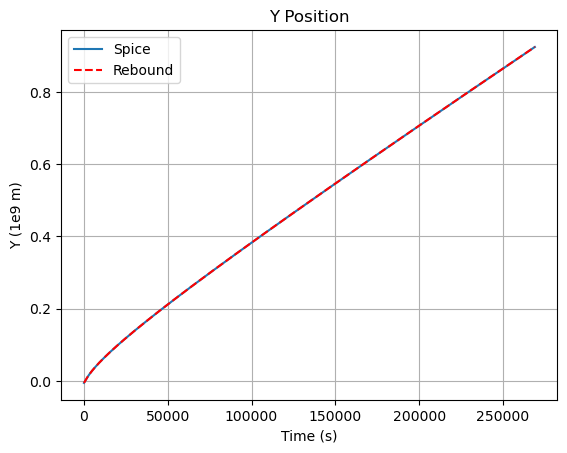

In [57]:
pio.renderers.default = "png"
plt.plot(tsh, xsh[:, 1]/1e9, label='Spice')
plt.plot(tsh, xsh_rb[:, 1]/1e9, 'r--', label='Rebound')
plt.title('Y Position')
plt.xlabel('Time (s)')
plt.ylabel('Y (1e9 m)')
plt.legend()
plt.grid(True)

* For the elliptical orbit

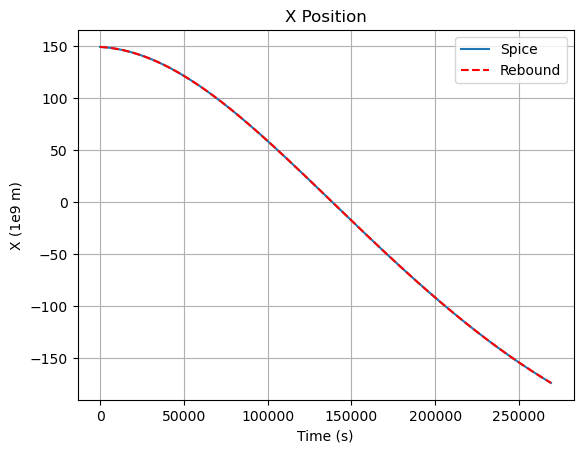

In [58]:
pio.renderers.default = "png"
plt.plot(tsh, rsh_sun_spy [:, 0]/1e9, label='Spice')
plt.plot(tsh, xsh_sun_rb[:, 0]/1e9, 'r--', label='Rebound')
plt.title('X Position')
plt.xlabel('Time (s)')
plt.ylabel('X (1e9 m)')
plt.legend()
plt.grid(True)

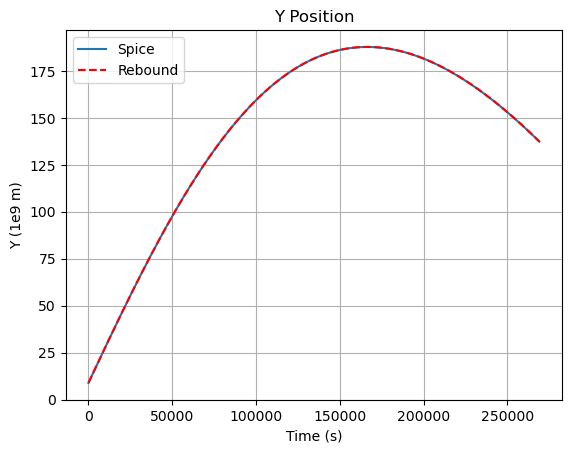

In [59]:
pio.renderers.default = "png"
plt.plot(tsh, rsh_sun_spy [:, 1]/1e9, label='Spice')
plt.plot(tsh, xsh_sun_rb[:, 1]/1e9, 'r--', label='Rebound')
plt.title('Y Position')
plt.xlabel('Time (s)')
plt.ylabel('Y (1e9 m)')
plt.legend()
plt.grid(True)